# 00: Titanic Kaggle Main Workflow

**Purpose:** Main workflow demonstrating data engineering and classical modelling on the Kaggle Titanic Competition dataset.

This workflow is fully matched with the OpenML Reference Workflow, utilizing identical features, custom estimators, visualizations, and pipeline components.

**Core workflow:**
```text
Load Data → Clean Data → Explore → Statistics Exercise → Feature Engineer → Custom Imputation → Split → Preprocessing Pipeline → GridSearchCV Model Search → Evaluation & ROC → Odds Coefficients → Predictions → Submission Export → Reflection
```


## 1. Environment and Library Setup

The notebook uses the standard Python data science stack: NumPy, Pandas, Matplotlib, Seaborn, and Scikit-Learn.
All package imports (including regular expressions `re` for title parsing and cross-validated searches) are declared in this initial cell to prepare the notebook for running cleanly in local and Colab environments.


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn import set_config

set_config(display="diagram")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 120

filename_prefix = "kaggle_"
print("✓ Step 1: Libraries and environment successfully set up!")


✓ Step 1: Libraries and environment successfully set up!


## 2. Dataset Ingestion

We load our raw dataset. For the Kaggle Competition, we load `train.csv` and `test.csv`.


In [2]:
possible_paths = [
    "../kaggle/",
    "./kaggle/",
    "../data/",
    "./data/",
    "/content/",
    "/content/kaggle/"
]

train = None
test = None

for base_path in possible_paths:
    train_file = os.path.join(base_path, "train.csv")
    test_file = os.path.join(base_path, "test.csv")
    if os.path.exists(train_file) and os.path.exists(test_file):
        train = pd.read_csv(train_file)
        test = pd.read_csv(test_file)
        print(f"✓ Kaggle datasets loaded successfully from local path: {base_path}")
        break

if train is None or test is None:
    print("Local Kaggle files not found. Attempting to download from remote GitHub repository fallback...")
    try:
        train_url = "https://raw.githubusercontent.com/sid0sid-ops/titanic-data-to-discovery/main/kaggle/train.csv"
        test_url = "https://raw.githubusercontent.com/sid0sid-ops/titanic-data-to-discovery/main/kaggle/test.csv"
        train = pd.read_csv(train_url)
        test = pd.read_csv(test_url)
        print("✓ Kaggle datasets loaded successfully from remote GitHub repository fallback!")
    except Exception as e:
        print(f"Remote download failed: {e}")

if train is None or test is None:
    raise FileNotFoundError("Could not load train.csv and test.csv from local paths or remote GitHub fallbacks.")

df = train.copy()
display(df.head())
print("Train Shape:", df.shape)
print("Test Shape:", test.shape)
df.info()


✓ Kaggle datasets loaded successfully from local path: ../kaggle/


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Train Shape: (891, 12)
Test Shape: (418, 11)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


## 3. Column Cleaning and Data Dictionary

Column names are normalized to lowercase and punctuation is simplified. Post-disaster fields (like `boat`, `body`, `home.dest`) are identified for removal to prevent **data leakage**.


In [3]:
df = df.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

df = df.replace("?", np.nan)
for numeric_column in ["age", "fare"]:
    if numeric_column in df.columns:
        df[numeric_column] = pd.to_numeric(df[numeric_column], errors="coerce")

if test is not None:
    test = test.copy()
    test.columns = (
        test.columns
        .str.strip()
        .str.lower()
        .str.replace(".", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )
    test = test.replace("?", np.nan)
    for numeric_column in ["age", "fare"]:
        if numeric_column in test.columns:
            test[numeric_column] = pd.to_numeric(test[numeric_column], errors="coerce")

display(pd.DataFrame({"cleaned_columns": df.columns}))
display(df.head())


,cleaned_columns
0,passengerid
1,survived
2,pclass
3,name
4,sex
5,age
6,sibsp
7,parch
8,ticket
9,fare


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Missing Value Analysis

Clean data is the foundation of reliable modeling. Missing values across key features are calculated and audited before visual modeling.


In [4]:
missing = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2),
    })
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)
display(missing)


,missing_count,missing_percent
cabin,687,77.10
age,177,19.87
embarked,2,0.22


## 5. Exploratory Data Analysis (EDA)

We conduct a complete, deep-dive EDA including the full gallery of 14 static plots and 4 interactive Plotly charts.
This gives a thorough visual understanding of demographic splits, distributions, port impacts, and high-dimensional correlations.


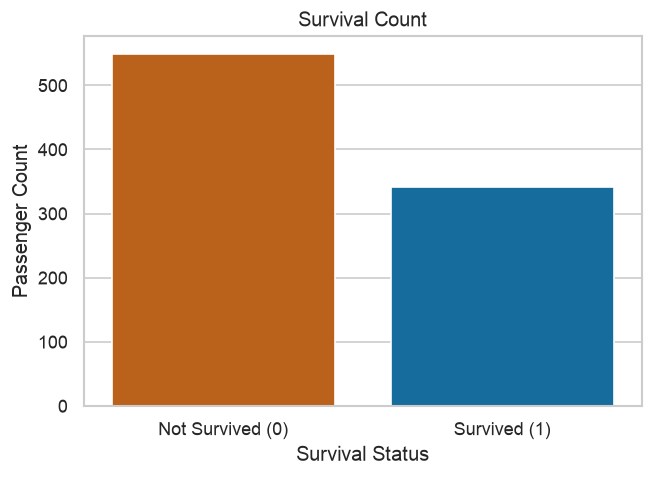

In [5]:
# 1. Survival Count Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="survived", hue="survived", palette=["#D55E00", "#0072B2"], legend=False)
plt.title("Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Count")
plt.xticks([0, 1], ["Not Survived (0)", "Survived (1)"])

export_path = "../public/assets/plots/" if os.path.exists("../public/") else "./plots/"
os.makedirs(export_path, exist_ok=True)
plt.savefig(os.path.join(export_path, f"{filename_prefix}survival_count.png"), dpi=150, bbox_inches="tight")
plt.show()


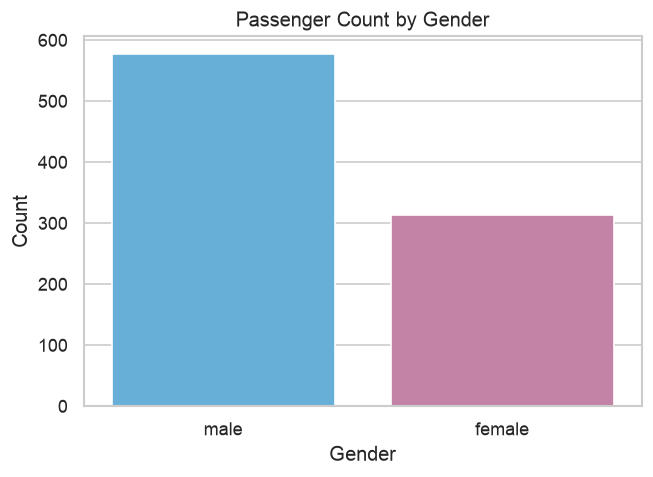

In [6]:
# 2. Sex Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex", hue="sex", palette=["#56B4E9", "#CC79A7"], legend=False)
plt.title("Passenger Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig(os.path.join(export_path, f"{filename_prefix}sex_count.png"), dpi=150, bbox_inches="tight")
plt.show()


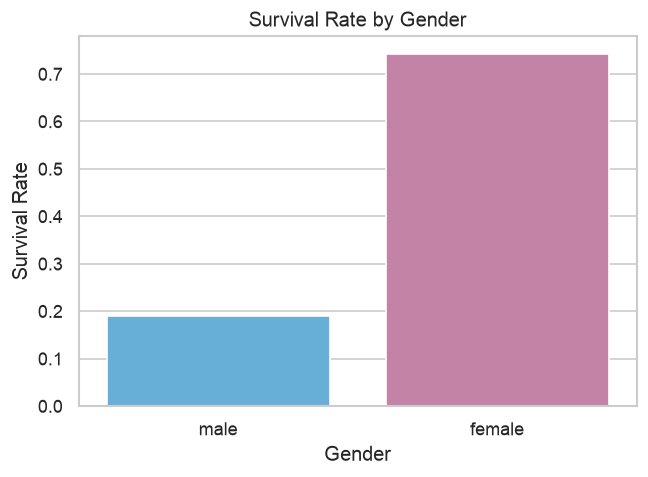

In [7]:
# 3. Survival Rate by Gender
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="sex", y="survived", hue="sex", palette=["#56B4E9", "#CC79A7"], errorbar=None, legend=False)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.savefig(os.path.join(export_path, f"{filename_prefix}survival_rate_by_sex.png"), dpi=150, bbox_inches="tight")
plt.show()


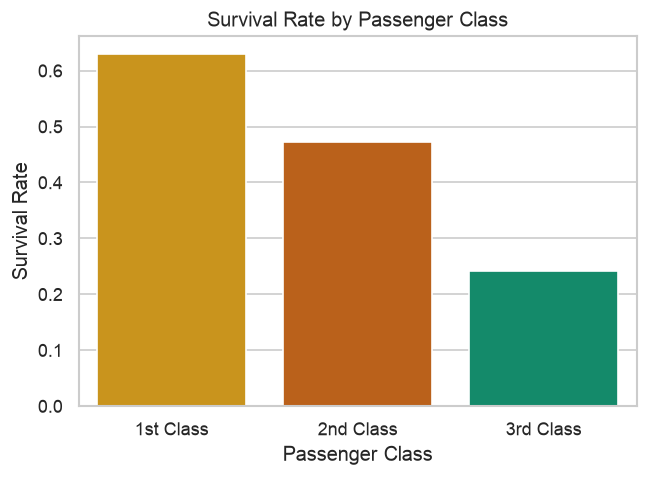

In [8]:
# 4. Survival Rate by Passenger Class
plt.figure(figsize=(6, 4))
df_temp = df.copy()
df_temp["pclass"] = df_temp["pclass"].map({1: "1st Class", 2: "2nd Class", 3: "3rd Class"})
sns.barplot(data=df_temp, x="pclass", y="survived", hue="pclass", palette=["#009E73", "#E69F00", "#D55E00"], order=["1st Class", "2nd Class", "3rd Class"], errorbar=None, legend=False)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.savefig(os.path.join(export_path, f"{filename_prefix}survival_rate_by_class.png"), dpi=150, bbox_inches="tight")
plt.show()


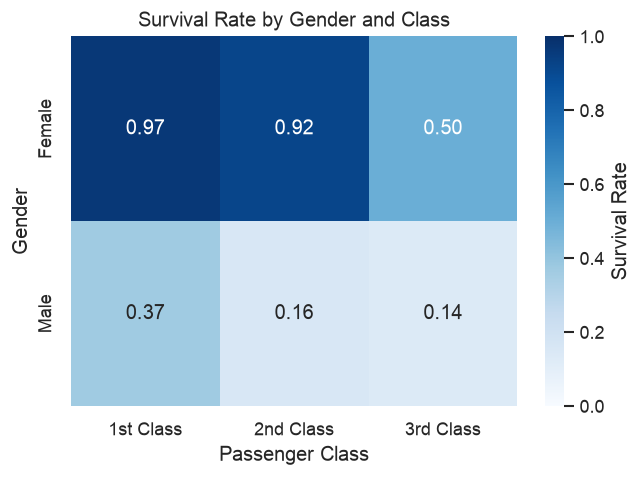

In [9]:
# 5. Survival Rate Heatmap by Gender and Class
plt.figure(figsize=(6, 4))
pivot = df.pivot_table(index="sex", columns="pclass", values="survived", aggfunc="mean")
pivot.columns = ["1st Class", "2nd Class", "3rd Class"]
pivot.index = [idx.capitalize() for idx in pivot.index]
sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".2f", cbar_kws={'label': 'Survival Rate'}, vmin=0, vmax=1)
plt.title("Survival Rate by Gender and Class")
plt.xlabel("Passenger Class")
plt.ylabel("Gender")

plt.savefig(os.path.join(export_path, f"{filename_prefix}survival_by_sex_class_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


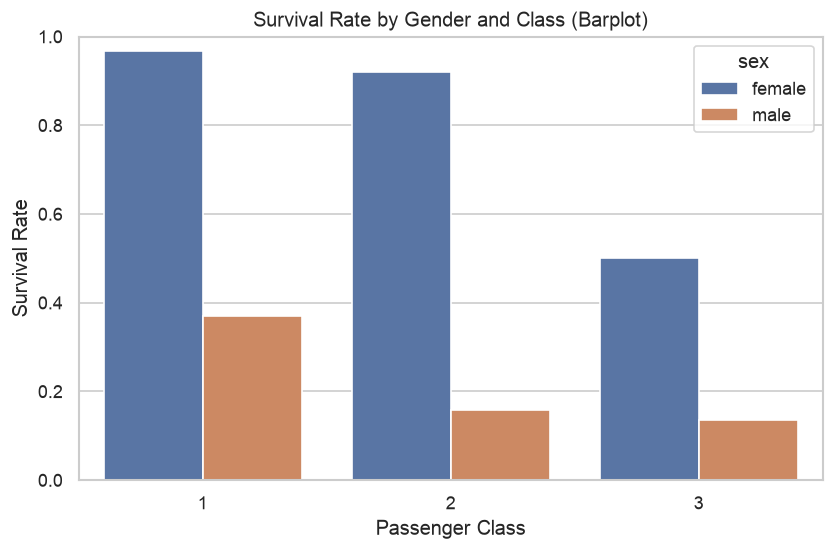

In [10]:
# 5.5. Survival Rate Barplot by Gender and Class
plt.figure(figsize=(8, 4.8))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival Rate by Gender and Class (Barplot)")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.savefig(os.path.join(export_path, f"{filename_prefix}survival_by_gender_class.png"), dpi=150, bbox_inches="tight")
plt.show()


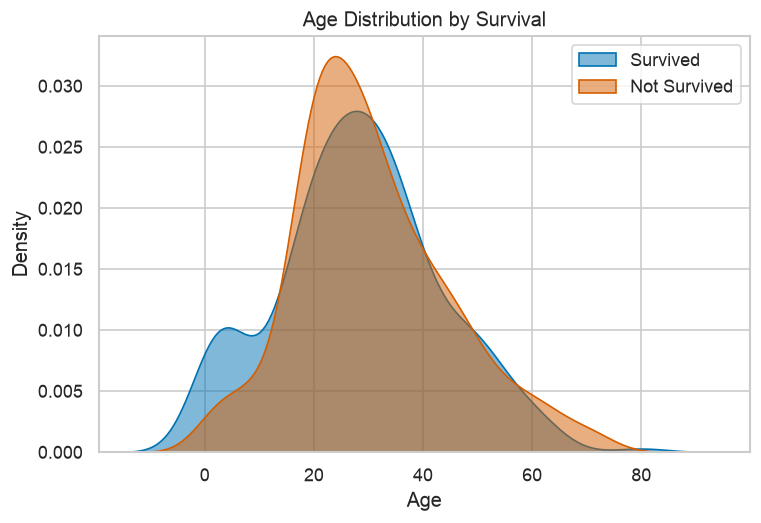

In [11]:
# 6. Age Distribution by Survival Density
plt.figure(figsize=(7, 4.5))
sns.kdeplot(data=df[df["survived"] == 1], x="age", fill=True, color="#0072B2", label="Survived", alpha=0.5)
sns.kdeplot(data=df[df["survived"] == 0], x="age", fill=True, color="#D55E00", label="Not Survived", alpha=0.5)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()

plt.savefig(os.path.join(export_path, f"{filename_prefix}age_distribution_survival.png"), dpi=150, bbox_inches="tight")
plt.show()


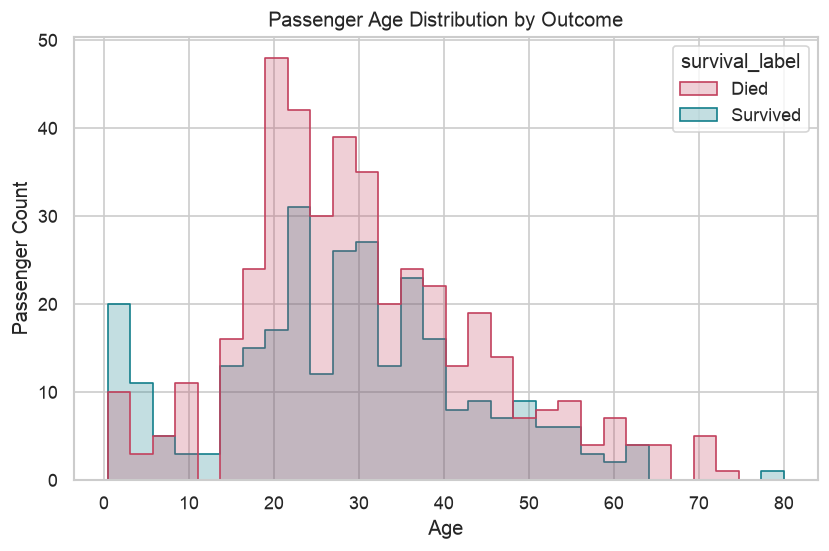

In [12]:
# 6.5. Passenger Age Distribution Histogram by Outcome
plt.figure(figsize=(8, 4.8))
outcome_palette = ["#c2415d", "#137f8b"]
df_temp = df.copy()
df_temp["survival_label"] = df_temp["survived"].map({0: "Died", 1: "Survived"})
sns.histplot(data=df_temp, x="age", hue="survival_label", bins=30, element="step", palette=outcome_palette)
plt.title("Passenger Age Distribution by Outcome")
plt.xlabel("Age")
plt.ylabel("Passenger Count")

plt.savefig(os.path.join(export_path, f"{filename_prefix}age_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


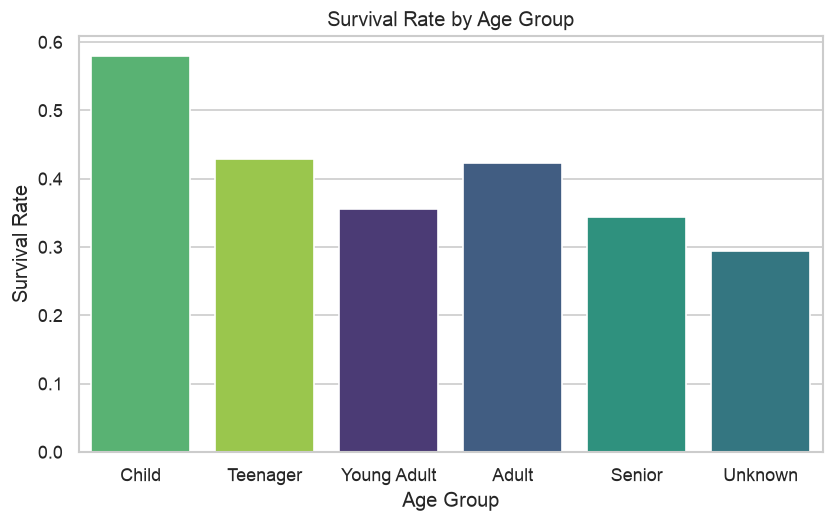

In [13]:
# 7. Survival Rate by Age Group
plt.figure(figsize=(8, 4.5))
df_temp = df.copy()
bins = [0, 12, 18, 30, 50, 120]
labels = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]
df_temp["age_group"] = pd.cut(df_temp["age"], bins=bins, labels=labels).astype(str)
df_temp["age_group"] = df_temp["age_group"].fillna("Unknown")

order = ["Child", "Teenager", "Young Adult", "Adult", "Senior", "Unknown"]
sns.barplot(data=df_temp, x="age_group", y="survived", order=order, hue="age_group", palette="viridis", errorbar=None, legend=False)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.savefig(os.path.join(export_path, f"{filename_prefix}age_group_survival.png"), dpi=150, bbox_inches="tight")
plt.show()


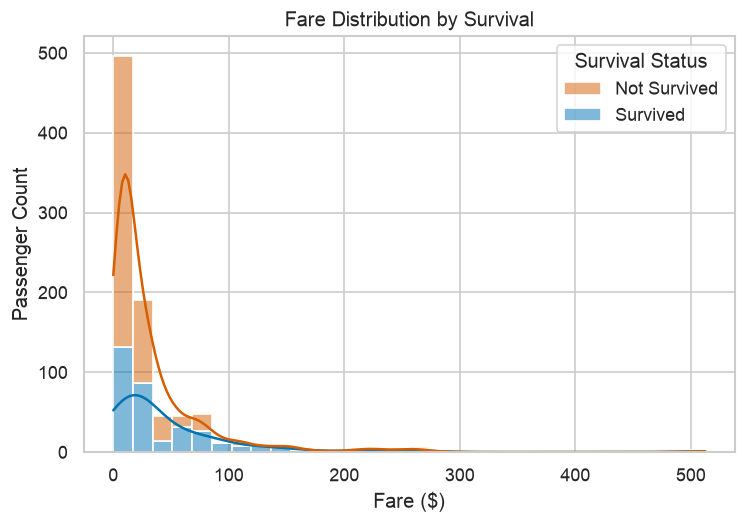

In [14]:
# 8. Fare Distribution Histogram
plt.figure(figsize=(7, 4.5))
df_temp = df.copy()
df_temp["Survival Status"] = df_temp["survived"].map({0: "Not Survived", 1: "Survived"})
sns.histplot(data=df_temp, x="fare", hue="Survival Status", palette={"Not Survived": "#D55E00", "Survived": "#0072B2"}, kde=True, bins=30, alpha=0.5, multiple="stack")
plt.title("Fare Distribution by Survival")
plt.xlabel("Fare ($)")
plt.ylabel("Passenger Count")

plt.savefig(os.path.join(export_path, f"{filename_prefix}fare_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


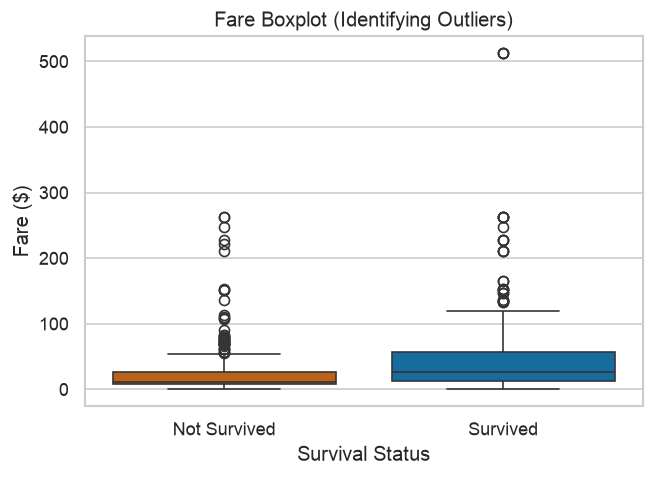

In [15]:
# 9. Fare Boxplot (Identifying Outliers)
plt.figure(figsize=(6, 4))
df_temp = df.copy()
df_temp["Survival Status"] = df_temp["survived"].map({0: "Not Survived", 1: "Survived"})
sns.boxplot(data=df_temp, x="Survival Status", y="fare", hue="Survival Status", palette={"Not Survived": "#D55E00", "Survived": "#0072B2"}, legend=False)
plt.title("Fare Boxplot (Identifying Outliers)")
plt.xlabel("Survival Status")
plt.ylabel("Fare ($)")

plt.savefig(os.path.join(export_path, f"{filename_prefix}fare_outlier_boxplot.png"), dpi=150, bbox_inches="tight")
plt.show()


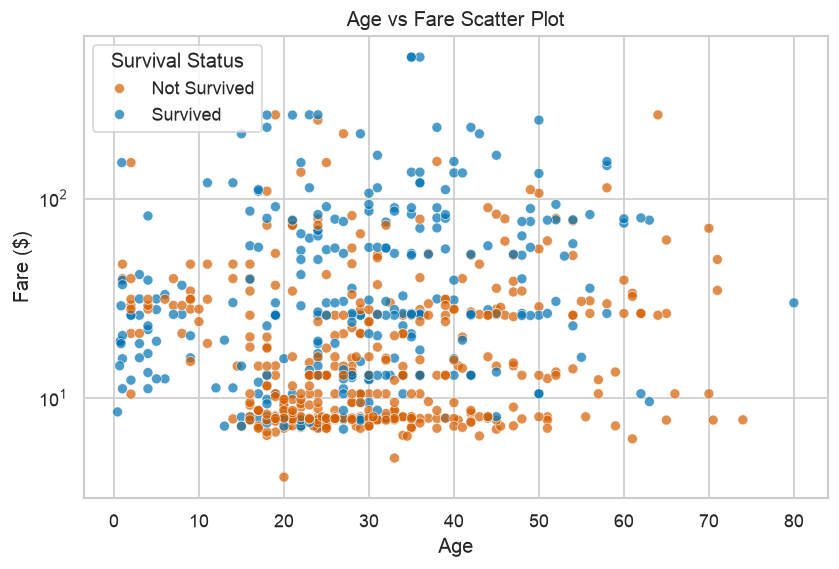

In [16]:
# 10. Age vs Fare Scatter Plot
plt.figure(figsize=(8, 5))
df_temp = df.copy()
df_temp["Survival Status"] = df_temp["survived"].map({0: "Not Survived", 1: "Survived"})
sns.scatterplot(data=df_temp, x="age", y="fare", hue="Survival Status", palette={"Not Survived": "#D55E00", "Survived": "#0072B2"}, alpha=0.7)
plt.title("Age vs Fare Scatter Plot")
plt.xlabel("Age")
plt.ylabel("Fare ($)")
plt.yscale("log")
plt.legend(title="Survival Status")

plt.savefig(os.path.join(export_path, f"{filename_prefix}age_fare_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()


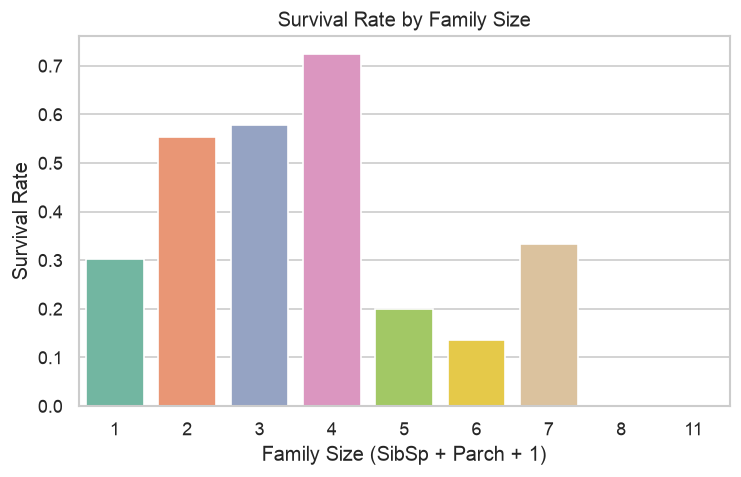

In [17]:
# 11. Survival Rate by Family Size
plt.figure(figsize=(7, 4))
df_temp = df.copy()
df_temp["family_size"] = df_temp["sibsp"] + df_temp["parch"] + 1
sns.barplot(data=df_temp, x="family_size", y="survived", hue="family_size", palette="Set2", errorbar=None, legend=False)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size (SibSp + Parch + 1)")
plt.ylabel("Survival Rate")

plt.savefig(os.path.join(export_path, f"{filename_prefix}family_size_survival.png"), dpi=150, bbox_inches="tight")
plt.show()


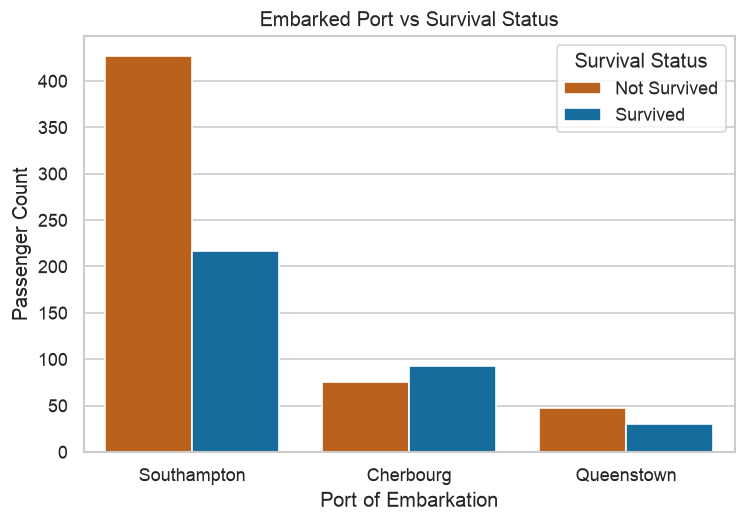

In [18]:
# 12. Embarked Location Survival and Death Distribution
plt.figure(figsize=(7, 4.5))
df_emb = df.dropna(subset=["embarked"]).copy()
df_emb["Survival Status"] = df_emb["survived"].map({0: "Not Survived", 1: "Survived"})
df_emb["embarked"] = df_emb["embarked"].map({"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})
sns.countplot(data=df_emb, x="embarked", hue="Survival Status", palette={"Not Survived": "#D55E00", "Survived": "#0072B2"})
plt.title("Embarked Port vs Survival Status")
plt.xlabel("Port of Embarkation")
plt.ylabel("Passenger Count")
plt.legend(title="Survival Status")

plt.savefig(os.path.join(export_path, f"{filename_prefix}embarked_survival.png"), dpi=150, bbox_inches="tight")
plt.show()


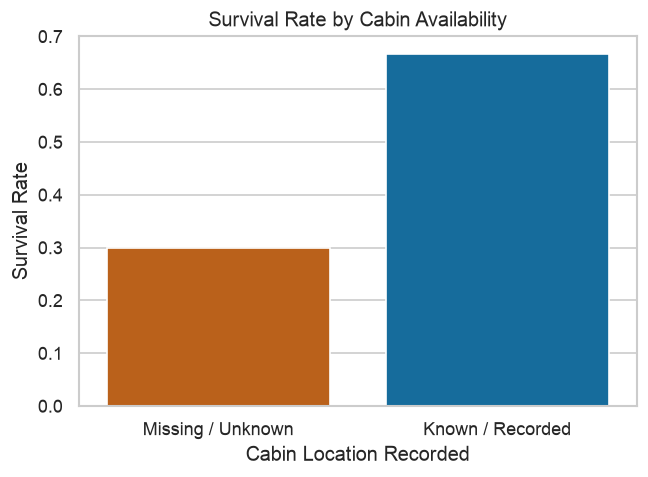

In [19]:
# 13. Survival Rate by Cabin Availability
plt.figure(figsize=(6, 4))
df_temp = df.copy()
df_temp["cabin_known"] = df_temp["cabin"].notna().map({True: "Known / Recorded", False: "Missing / Unknown"})
sns.barplot(data=df_temp, x="cabin_known", y="survived", hue="cabin_known", palette=["#D55E00", "#0072B2"], order=["Missing / Unknown", "Known / Recorded"], errorbar=None, legend=False)
plt.title("Survival Rate by Cabin Availability")
plt.xlabel("Cabin Location Recorded")
plt.ylabel("Survival Rate")

plt.savefig(os.path.join(export_path, f"{filename_prefix}cabin_known_survival.png"), dpi=150, bbox_inches="tight")
plt.show()


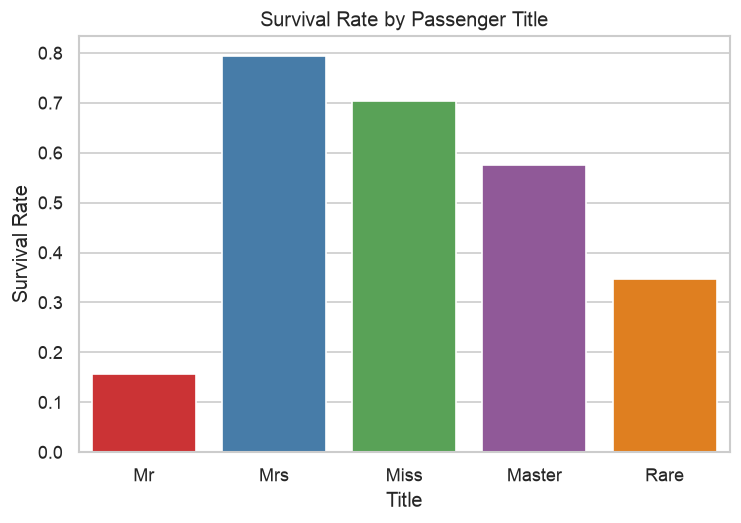

In [20]:
# 14. Title Groupings vs Survival
plt.figure(figsize=(7, 4.5))
df_temp = df.copy()
def get_title(name):
    if not isinstance(name, str):
        return "Mr"
    match = re.search(r",\s*([^.]+)\.", name)
    return match.group(1).strip() if match else "Mr"
df_temp["title"] = df_temp["name"].apply(get_title)
title_mapping = {
    "Mr": "Mr", "Mrs": "Mrs", "Miss": "Miss", "Master": "Master",
    "Mme": "Mrs", "Ms": "Miss", "Mlle": "Miss"
}
df_temp["title"] = df_temp["title"].map(title_mapping).fillna("Rare")

sns.barplot(data=df_temp, x="title", y="survived", hue="title", palette="Set1", errorbar=None, legend=False)
plt.title("Survival Rate by Passenger Title")
plt.xlabel("Title")
plt.ylabel("Survival Rate")

plt.savefig(os.path.join(export_path, f"{filename_prefix}title_survival.png"), dpi=150, bbox_inches="tight")
plt.show()


### Interactive Exploratory Plots
Below we render four dynamic Plotly visualizations. These plots allow interactive panning, zooming, and hover annotations. Note that interactive Plotly plots require a running Python kernel (such as in Jupyter Notebook or Google Colab) to render dynamically.


In [21]:
# 1. Interactive Sunburst (Ticket Class -> Sex -> Survival Status)
vis_df = df.copy()
vis_df["Survival Status"] = vis_df["survived"].map({0: "Died", 1: "Survived"})
vis_df["Ticket Class"] = vis_df["pclass"].map({1: "1st Class", 2: "2nd Class", 3: "3rd Class"})

fig_sunburst = px.sunburst(
    vis_df, 
    path=["Ticket Class", "sex", "Survival Status"], 
    title="Interactive Sunburst: Class -> Gender -> Survival Status",
    color="Survival Status",
    color_discrete_map={"Survived": "#2ca02c", "Died": "#d62728"}
)
fig_sunburst.update_layout(margin=dict(t=40, l=0, r=0, b=0))
fig_sunburst.show()


In [22]:
# 2. Interactive Scatter (Age vs. Fare)
vis_df = df.copy()
vis_df["Survival Status"] = vis_df["survived"].map({0: "Died", 1: "Survived"})
vis_df["Ticket Class"] = vis_df["pclass"].map({1: "1st Class", 2: "2nd Class", 3: "3rd Class"})

fig_scatter = px.scatter(
    vis_df.dropna(subset=["age", "fare"]), 
    x="age", 
    y="fare", 
    color="Survival Status",
    hover_name="name",
    log_y=True,
    color_discrete_map={"Survived": "#2678B2", "Died": "#FD7F28"},
    title="Interactive Scatter: Age vs. Fare (Log Scale, Color-coded by Survival)"
)
fig_scatter.update_layout(xaxis_title="Age (Years)", yaxis_title="Fare (GBP, Log Scale)")
fig_scatter.show()


In [23]:
# 3. Interactive 3D Scatter (Age vs. Fare vs. Pclass)
vis_df = df.copy()
vis_df["Survival Status"] = vis_df["survived"].map({0: "Died", 1: "Survived"})

fig_3d = px.scatter_3d(
    vis_df.dropna(subset=["age", "fare"]), 
    x="age", 
    y="fare", 
    z="pclass", 
    color="Survival Status",
    log_y=True,
    hover_name="name",
    color_discrete_map={"Survived": "#2ca02c", "Died": "#d62728"},
    title="Interactive 3D Scatter: Age vs. Fare vs. Pclass"
)
fig_3d.show()


In [24]:
# 4. Interactive Parallel Categories Flow
vis_df = df.copy()
vis_df["Survival Status"] = vis_df["survived"].map({0: "Died", 1: "Survived"})
vis_df["Ticket Class"] = vis_df["pclass"].map({1: "1st Class", 2: "2nd Class", 3: "3rd Class"})
vis_df["Sex"] = vis_df["sex"].astype(str).str.strip().str.title()
vis_df["Embarked Port"] = vis_df["embarked"].astype(str).str.strip().str.upper().map({
    "S": "Southampton",
    "C": "Cherbourg",
    "Q": "Queenstown",
})
vis_df["Ticket Class"] = pd.Categorical(
    vis_df["Ticket Class"],
    categories=["1st Class", "2nd Class", "3rd Class"],
    ordered=True,
)
vis_df["Sex"] = pd.Categorical(vis_df["Sex"], categories=["Female", "Male"], ordered=True)
vis_df["Embarked Port"] = pd.Categorical(
    vis_df["Embarked Port"],
    categories=["Cherbourg", "Queenstown", "Southampton"],
    ordered=True,
)
vis_df["Survival Status"] = pd.Categorical(
    vis_df["Survival Status"],
    categories=["Died", "Survived"],
    ordered=True,
)
parcat_df = vis_df.dropna(subset=["Embarked Port", "Sex", "Ticket Class", "Survival Status"])

fig_parcat = px.parallel_categories(
    parcat_df,
    dimensions=["Ticket Class", "Sex", "Embarked Port", "Survival Status"],
    color="survived", 
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Parallel Categories: Demographic Flow to Survival Outcome"
)
fig_parcat.update_layout(
    autosize=False,
    height=700,
    width=1300,
    margin=dict(t=90, l=80, r=180, b=120),
    font=dict(size=13),
)
fig_parcat.show()


## 6. Hands-On Exercise: Exploring Statistics in the Titanic Dataset

This section contains the hands-on statistics exercises matching your classroom curriculum for June 18, 2026.

### Part 1: Descriptive Statistics
We compute the mean and median of Age and Fare, calculate the overall survival rate, and plot the passenger age distribution.


=== Descriptive Statistics ===
Mean Age       : 29.70
Median Age     : 28.00
Mean Fare      : 32.20
Median Fare    : 14.45
Survival Rate  : 38.38%


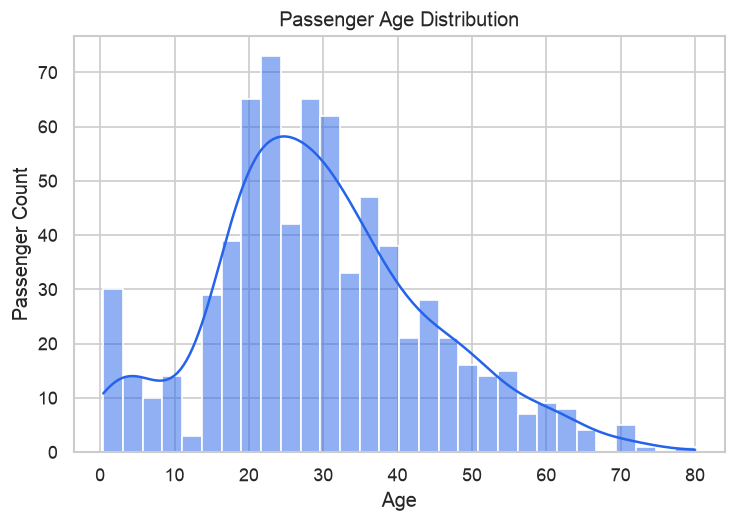

In [25]:
# Part 1: Descriptive statistics
age_mean = df["age"].mean()
age_median = df["age"].median()
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
survival_rate = df["survived"].mean()

print("=== Descriptive Statistics ===")
print(f"Mean Age       : {age_mean:.2f}")
print(f"Median Age     : {age_median:.2f}")
print(f"Mean Fare      : {fare_mean:.2f}")
print(f"Median Fare    : {fare_median:.2f}")
print(f"Survival Rate  : {survival_rate:.2%}")

export_path = "../public/assets/plots/" if os.path.exists("../public/") else "./plots/"
os.makedirs(export_path, exist_ok=True)

plt.figure(figsize=(7, 4.5))
sns.histplot(data=df, x="age", bins=30, kde=True, color="#2563eb")
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.savefig(os.path.join(export_path, f"{filename_prefix}statistics_age_histogram.png"), bbox_inches="tight", dpi=150)
plt.show()


### Part 2: Variance & Correlation
We calculate the variance and standard deviation of passenger Fares, then create one consolidated correlation heatmap for selected survival-related features.


=== Fare Dispersion ===
Fare Variance          : 2469.4368
Fare Standard Deviation: 49.6934


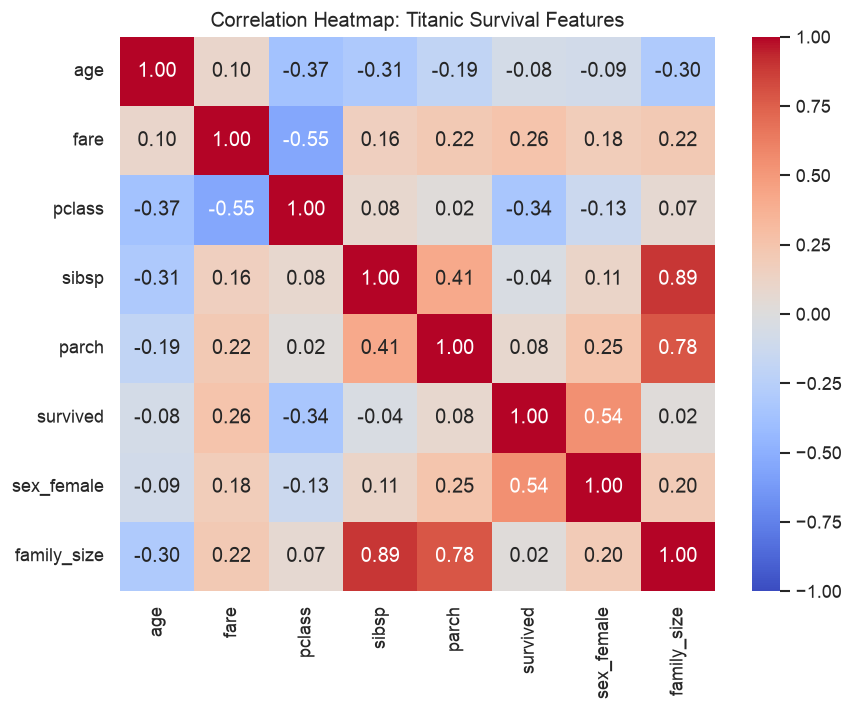

In [26]:
# Part 2: variance and one consolidated correlation heatmap
fare_var = df["fare"].var()
fare_std = df["fare"].std()
print("=== Fare Dispersion ===")
print(f"Fare Variance          : {fare_var:.4f}")
print(f"Fare Standard Deviation: {fare_std:.4f}")

correlation_source = df[["age", "fare", "pclass", "sibsp", "parch", "survived"]].copy()
correlation_source["sex_female"] = (df["sex"] == "female").astype(int)
correlation_source["family_size"] = df["sibsp"] + df["parch"] + 1
correlation = correlation_source.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", center=0, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Titanic Survival Features")

# Save under both names so existing reports/web assets remain compatible while showing only one heatmap here.
plt.savefig(os.path.join(export_path, f"{filename_prefix}statistics_correlation.png"), bbox_inches="tight", dpi=150)
plt.savefig(os.path.join(export_path, f"{filename_prefix}correlation_heatmap.png"), bbox_inches="tight", dpi=150)
plt.show()


### Part 3: Hypothesis Testing
We run a two-sample independent Student's t-test to determine if the difference in survival rates between women and men is statistically significant.


In [27]:
from scipy.stats import ttest_ind

male = df[df["sex"] == "male"]["survived"]
female = df[df["sex"] == "female"]["survived"]

t_stat, p_val = ttest_ind(female, male)
print("=== Student's t-Test Results ===")
print(f"t-statistic : {t_stat:.6f}")
print(f"p-value     : {p_val:.4e}")

if p_val < 0.05:
    print("\nInterpretation: Since the p-value is less than 0.05, the difference is STATISTICALLY SIGNIFICANT.")
    print("We reject the null hypothesis; women had a significantly higher survival rate than men.")
else:
    print("\nInterpretation: Since the p-value is greater than 0.05, the difference is NOT statistically significant.")


=== Student's t-Test Results ===
t-statistic : 19.297817
p-value     : 1.4061e-69

Interpretation: Since the p-value is less than 0.05, the difference is STATISTICALLY SIGNIFICANT.
We reject the null hypothesis; women had a significantly higher survival rate than men.


### Part 4: Regression
We construct a simple Logistic Regression classifier using Age, Fare, and Pclass to estimate the survival probability of a hypothetical passenger.


In [28]:
# Prepare data
X_simple = df[["age", "fare", "pclass"]].copy()
y_simple = df["survived"]

# Impute missing values using the mean
X_simple = X_simple.fillna(X_simple.mean())

# Train simple model
simple_model = LogisticRegression(solver="liblinear", random_state=42)
simple_model.fit(X_simple, y_simple)

# Predict survival for a custom passenger: Age=25, Fare=50, Pclass=2
custom_test = pd.DataFrame([[25.0, 50.0, 2]], columns=X_simple.columns)
pred_survival = simple_model.predict(custom_test)[0]
pred_prob = simple_model.predict_proba(custom_test)[0, 1]

print("=== Simple Logistic Regression Predictor ===")
print("Passenger Profile  : Age=25, Fare=50, Pclass=2")
print(f"Survival Probability: {pred_prob*100:.2f}%")
print(f"Prediction Outcome : {'SURVIVES' if pred_survival == 1 else 'DECEASED'}")


=== Simple Logistic Regression Predictor ===
Passenger Profile  : Age=25, Fare=50, Pclass=2
Survival Probability: 49.37%
Prediction Outcome : DECEASED


## 7. Feature Engineering Transformer

We build a custom Scikit-Learn transformer class `TitanicFeatureEngineer` to perform feature engineering.
This creates family features (`family_size`, `is_alone`), extracts passenger name prefixes to create a `title` group, and flags cabin indicators (`has_cabin`) while cleanly dropping leakage and string identifiers.


In [29]:
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out["family_size"] = X_out["sibsp"] + X_out["parch"] + 1
        X_out["is_alone"] = (X_out["family_size"] == 1).astype(int)

        def extract_title(name):
            if not isinstance(name, str):
                return "Mr"
            match = re.search(r",\s*([^.]+)\.", name)
            return match.group(1).strip() if match else "Mr"

        X_out["title"] = X_out["name"].apply(extract_title)
        title_mapping = {
            "Mr": "Mr",
            "Mrs": "Mrs",
            "Miss": "Miss",
            "Master": "Master",
            "Mme": "Mrs",
            "Ms": "Miss",
            "Mlle": "Miss",
        }
        X_out["title"] = X_out["title"].map(title_mapping).fillna("Rare")
        X_out["has_cabin"] = X_out["cabin"].notna().astype(int)

        leakage_or_raw = ["passengerid", "name", "ticket", "cabin", "boat", "body", "home_dest"]
        return X_out.drop(columns=[col for col in leakage_or_raw if col in X_out.columns])


## 8. Custom Imputation (Leakage-Safe)

Simple global median imputation ignores passenger demographics. We create a custom `GroupMedianAgeImputer` class that computes median age grouped by passenger class and gender, fitting only on the training folds during cross-validation to prevent data leakage.


In [30]:
class GroupMedianAgeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, age_col="age", group_cols=("pclass", "sex")):
        self.age_col = age_col
        self.group_cols = group_cols
        self.group_medians_ = {}
        self.global_median_ = None

    def fit(self, X, y=None):
        X_fit = X.copy()
        self.global_median_ = X_fit[self.age_col].median()
        medians = X_fit.groupby(list(self.group_cols), dropna=False)[self.age_col].median()
        self.group_medians_ = medians.to_dict()
        return self

    def transform(self, X):
        X_out = X.copy()
        def fill_age(row):
            if pd.isna(row[self.age_col]):
                key = tuple(row[col] for col in self.group_cols)
                return self.group_medians_.get(key, self.global_median_)
            return row[self.age_col]
        X_out[self.age_col] = X_out.apply(fill_age, axis=1)
        return X_out


## 9. Train/Test Split

We perform a stratified 80-20 partition (`stratify=y`) to split feature attributes and survival targets.


In [31]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "cabin", "name"]
X = df.drop(columns=["survived"])
y = df["survived"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (712, 11) | Test shape: (179, 11)


## 10. Preprocessing Pipeline

We build a `ColumnTransformer` preprocessing pipeline mapping standard numeric and categorical features.


In [32]:
numeric_features = ["age", "sibsp", "parch", "fare", "family_size"]
categorical_features = ["pclass", "sex", "embarked", "is_alone", "title", "has_cabin"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


## 11. GridSearchCV Model Search

We set up a grid search searching over Logistic Regression hyper-parameters to find the optimal C regularization parameter.


In [33]:
base_pipeline = Pipeline(steps=[
    ("group_age_imputer", GroupMedianAgeImputer()),
    ("feature_engineer", TitanicFeatureEngineer()),
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, solver="liblinear", random_state=42))
])

param_grid = {
    "classifier__C": [0.1, 1.0, 10.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("GridSearchCV model search complete.")
print("Best params:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


GridSearchCV model search complete.
Best params: {'classifier__C': 1.0}
Best cross-validation accuracy: 0.8301


## 12. Model Evaluation & ROC Curve

We predict outcomes on the holdout test set using the chosen optimal pipeline and generate accuracy metrics, classification reports, and the ROC curve.


Holdout Test Accuracy: 0.8156
ROC-AUC score: 0.8636

Confusion Matrix:
 [[97 13]
 [20 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



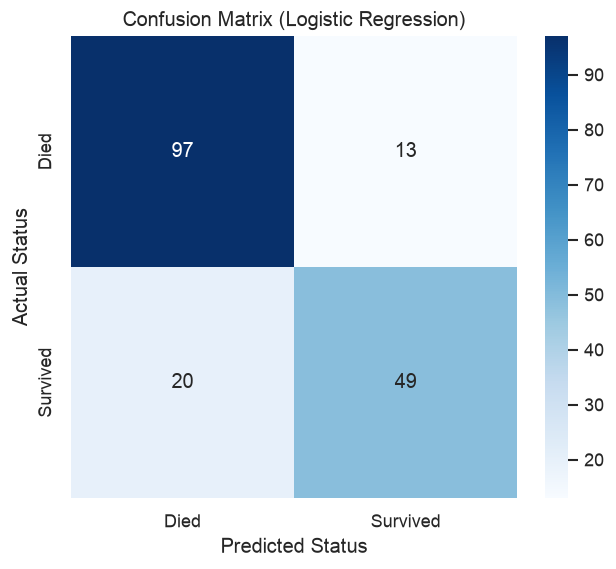

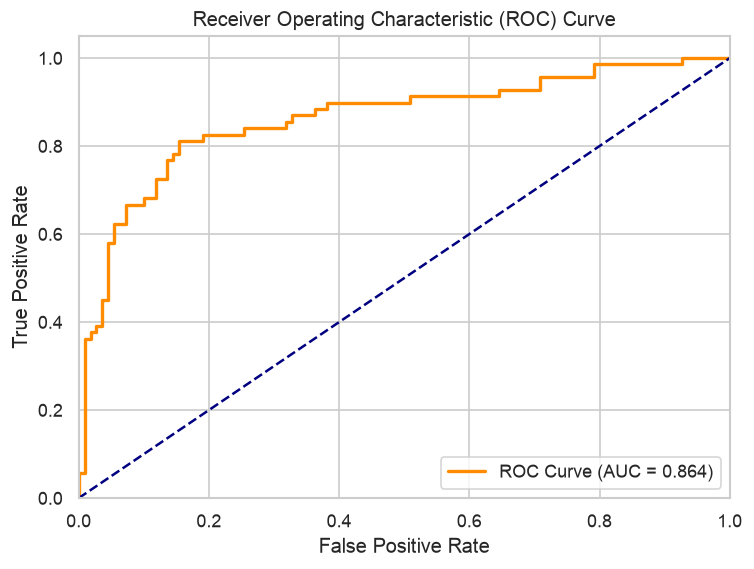

In [34]:
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(f"Holdout Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Export Plot 15: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.ylabel("Actual Status")
plt.xlabel("Predicted Status")
plt.title("Confusion Matrix (Logistic Regression)")
plt.savefig(os.path.join(export_path, f"{filename_prefix}confusion_matrix.png"), bbox_inches="tight", dpi=150)
plt.show()

# Export Plot 16: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.savefig(os.path.join(export_path, f"{filename_prefix}roc_curve.png"), bbox_inches="tight", dpi=150)
plt.show()

def predict_and_print(passenger_df, pipeline_model):
    prediction = pipeline_model.predict(passenger_df)
    probability = pipeline_model.predict_proba(passenger_df)[:, 1]

    for idx, row in passenger_df.iterrows():
        outcome = "SURVIVES" if prediction[idx] == 1 else "NOT SURVIVED"
        print(f"Passenger: {row['name']:<30} | Class: {row['pclass']} | Sex: {row['sex']:<6} | Probability: {probability[idx]:.4f} ({probability[idx]*100:.1f}%) | Prediction: {outcome}")


## 13. Pipeline Diagram

Displaying the Scikit-Learn visual block diagram of the optimal pipeline.


In [35]:
best_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('group_age_imputer', ...), ('feature_engineer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,age_col,'age'
,group_cols,"('pclass', ...)"
Name,Type,Value
global_median_,float64,28.5
group_medians_,dict,"{(1, 'female'): 35.0, (1, 'male'): 40.0, (2, 'female'): 29.0, (2, 'male'): 30.0, ...}"


## 14. Log-Odds Coefficients

Displaying feature importances or logistic regression log-odds parameters mapping the direction of influence.


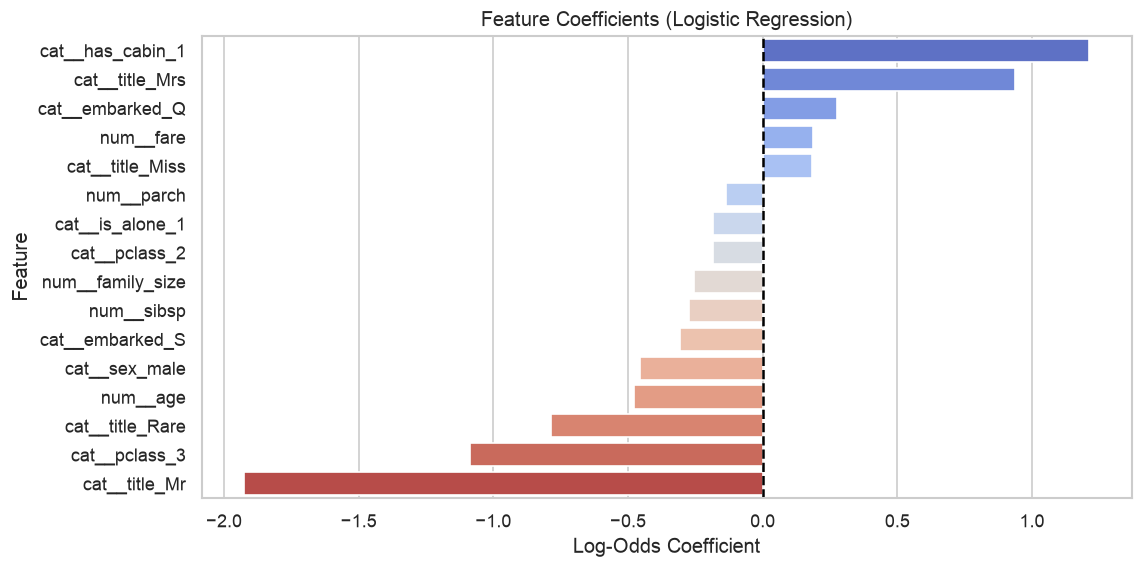

,Feature,Coefficient,Odds Ratio
15,cat__has_cabin_1,1.213109,3.363928
13,cat__title_Mrs,0.938215,2.555416
8,cat__embarked_Q,0.275019,1.316555
3,num__fare,0.186320,1.204808
11,cat__title_Miss,0.182055,1.199680
2,num__parch,-0.136310,0.872572
10,cat__is_alone_1,-0.184442,0.831568
5,cat__pclass_2,-0.184502,0.831518
4,num__family_size,-0.253400,0.776157
1,num__sibsp,-0.271908,0.761924


In [36]:
preprocess_step = best_pipeline.named_steps["preprocess"]
encoded_feature_names = preprocess_step.get_feature_names_out()
classifier = best_pipeline.named_steps["classifier"]

if isinstance(classifier, LogisticRegression):
    interpretation = pd.DataFrame({
        "Feature": encoded_feature_names,
        "Coefficient": classifier.coef_[0],
        "Odds Ratio": np.exp(classifier.coef_[0]),
    }).sort_values("Coefficient", ascending=False)

    # Plot coefficients
    plt.figure(figsize=(10, 5))
    sns.barplot(data=interpretation, x="Coefficient", y="Feature", hue="Feature", palette="coolwarm", legend=False)
    plt.axvline(x=0, color="black", linestyle="--")
    plt.title("Feature Coefficients (Logistic Regression)")
    plt.xlabel("Log-Odds Coefficient")
    plt.savefig(os.path.join(export_path, f"{filename_prefix}feature_importance.png"), bbox_inches="tight", dpi=150)
    plt.show()

    display(interpretation)
else:
    interpretation = pd.DataFrame({
        "Feature": encoded_feature_names,
        "Importance": classifier.feature_importances_
    }).sort_values("Importance", ascending=False)

    # Plot importances
    plt.figure(figsize=(10, 5))
    sns.barplot(data=interpretation, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title("Feature Importances")
    plt.xlabel("Importance Score")
    plt.savefig(os.path.join(export_path, f"{filename_prefix}feature_importance.png"), bbox_inches="tight", dpi=150)
    plt.show()

    display(interpretation)


## 15. Passenger Predictions & Custom Colab Test Sandbox

Evaluating custom passenger scenarios matching the Jupyter notebook showcase profiles.
You can also copy the custom passenger Python script from the companion website sandbox and paste it into the code cell below to run predictions live!


In [37]:
model = best_pipeline

custom_passengers = pd.DataFrame([
    {"pclass": 3, "sex": "male", "age": 22.0, "sibsp": 0, "parch": 0, "fare": 7.25, "embarked": "S", "cabin": np.nan, "name": "Single, Mr. Third Class"},
    {"pclass": 1, "sex": "female", "age": 38.0, "sibsp": 1, "parch": 0, "fare": 71.28, "embarked": "C", "cabin": "C85", "name": "Married, Mrs. First Class"},
    {"pclass": 2, "sex": "male", "age": 6.0, "sibsp": 1, "parch": 1, "fare": 26.00, "embarked": "S", "cabin": np.nan, "name": "Child, Master. Second Class"}
])

print("LIVE SIMULATION PREDICTIONS")
print("=" * 60)
predict_and_print(custom_passengers, model)


LIVE SIMULATION PREDICTIONS
Passenger: Single, Mr. Third Class        | Class: 3 | Sex: male   | Probability: 0.0992 (9.9%) | Prediction: NOT SURVIVED
Passenger: Married, Mrs. First Class      | Class: 1 | Sex: female | Probability: 0.9594 (95.9%) | Prediction: SURVIVES
Passenger: Child, Master. Second Class    | Class: 2 | Sex: male   | Probability: 0.6710 (67.1%) | Prediction: SURVIVES


## 16. Export Kaggle Submission

Lastly, we fit our best parameter pipeline on the *complete* training dataset (to maximize model exposure) and generate predictions on Kaggle's unseen `test` profiles.


In [38]:
# Fit the optimal pipeline on the full training set (X, y)
final_pipeline = Pipeline(steps=[
    ("group_age_imputer", GroupMedianAgeImputer()),
    ("feature_engineer", TitanicFeatureEngineer()),
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(C=grid_search.best_params_["classifier__C"], max_iter=1000, solver="liblinear", random_state=42))
])
final_pipeline.fit(X, y)

# Run predictions on clean Kaggle test set
test_preds = final_pipeline.predict(test)

# Format submission layout
submission = pd.DataFrame({
    "PassengerId": test["passengerid"],
    "Survived": test_preds
})

submission.columns = ["PassengerId", "Survived"]

# Export to CSV
try:
    os.makedirs("../submissions/", exist_ok=True)
    sub_path = "../submissions/submission_best_classical.csv"
except Exception:
    os.makedirs("submissions/", exist_ok=True)
    sub_path = "submissions/submission_best_classical.csv"
submission.to_csv(sub_path, index=False)

print(f"✓ Saved Kaggle predictions to: {sub_path}")
print(submission.head(10))


✓ Saved Kaggle predictions to: ../submissions/submission_best_classical.csv
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


## 17. Economic and Real-World Relevance

The Titanic classification problem serves as a proxy for safety engineering, risk profiling, and policy analysis in maritime operations, insurance, and medicine.


## 18. Data Science Mindset

- **Be thorough:** Look for missingness and data anomalies early.
- **Be leakage-aware:** Always impute and engineer features within the pipeline cross-validation folds.
- **Be visual:** A single well-crafted plot carries more weight than dozens of printed statistics tables.


## 19. Final Reflection

Data science is more than just parameter tuning. It is about understanding the human story beneath the rows, cleaning responsibly, and validating results against realistic baselines.
